In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

print("imports ok")

imports ok


In [3]:
dataset = load_dataset("stanfordnlp/imdb")
print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

C:\Users\User\Desktop\sentiment_analysis\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--stanfordnlp--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
# Μετατροπή σε DataFrame για πιο εύκολη δουλειά
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(train_df.shape)
print(train_df.head())

(25000, 2)
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


label
0    12500
1    12500
Name: count, dtype: int64




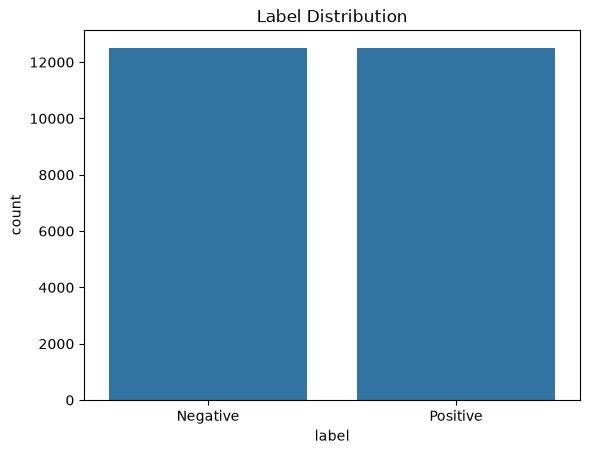

In [5]:
# Κατανομή positive/negative
print(train_df['label'].value_counts())
print("\n")

# Visualization
sns.countplot(x='label', data=train_df)
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Label Distribution')
plt.show()

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64


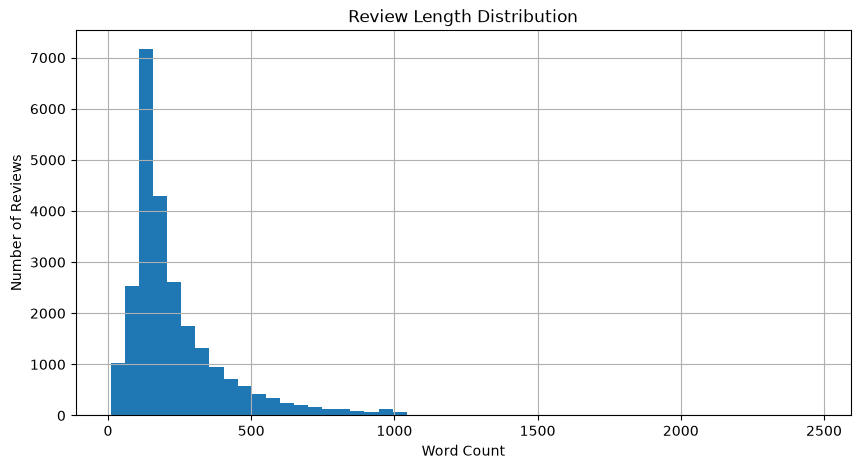

In [6]:
# Μήκος reviews σε λέξεις
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

print(train_df['word_count'].describe())

train_df['word_count'].hist(bins=50, figsize=(10,5))
plt.title('Review Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Number of Reviews')
plt.show()

In [7]:
# Ένα negative review
print("NEGATIVE REVIEW:")
print(train_df[train_df['label']==0]['text'].iloc[0])
print("\n" + "="*50 + "\n")

# Ένα positive review
print("POSITIVE REVIEW:")
print(train_df[train_df['label']==1]['text'].iloc[0])

NEGATIVE REVIEW:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

In [8]:
from collections import Counter
import re

def get_top_words(df, label, n=20):
    texts = df[df['label']==label]['text'].str.lower()
    words = ' '.join(texts).split()
    # Αφαιρούμε προσωρινά stopwords χειροκίνητα
    stopwords = {'the','a','an','is','it','in','of','and','to','this','was','that','i','for','with','on','at','as','by','be','are','have','had','but','not','from','or','his','her','he','she','they','we','you','my','me','so','do','its','been','has','their','there','than','one','all','would','about','more','who','film','movie','just','like','very','what','no','up','out','if','which','when','also','into','how','some','were','after','time','even','only','can','then','too','him','story','good','great'}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

print("TOP NEGATIVE WORDS:")
print(get_top_words(train_df, 0))

print("\nTOP POSITIVE WORDS:")
print(get_top_words(train_df, 1))

TOP NEGATIVE WORDS:
[('/><br', 26318), ("it's", 8007), ('really', 5806), ('bad', 5335), ('see', 5010), ('get', 4851), ('because', 4804), ("don't", 4775), ('any', 4552), ('much', 4524), ('could', 4487), ('make', 4454), ('people', 4017), ('other', 3961), ('will', 3866), ('made', 3800), ('first', 3790), ('most', 3768), ('/>the', 3701), ('think', 3406)]

TOP POSITIVE WORDS:
[('/><br', 24617), ("it's", 7963), ('see', 5400), ('really', 5259), ('will', 5060), ('most', 4709), ('other', 4268), ('much', 4215), ('first', 4195), ('get', 4108), ('because', 3932), ('well', 3803), ('best', 3733), ('/>the', 3708), ('people', 3659), ('many', 3617), ('love', 3543), ('two', 3384), ('think', 3367), ('made', 3241)]
